In [1]:
pip install neuralhydrology


Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [4]:

import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from neuralhydrology.evaluation import metrics, get_tester
from neuralhydrology.nh_run import start_run, eval_run
from neuralhydrology.utils.config import Config

In [4]:
#1st Scenario running (without soil moisture)
start_run(config_file=Path("/Users/gautam/Research/codesforresearch/percentsaturation/after first review/Voronoi/1_basin.yml"))

2026-03-01 12:50:57,765: Logging to /Users/gautam/Research/codesforresearch/percentsaturation/after first review/Voronoi/runs/no_soil_0103_125057/output.log initialized.
2026-03-01 12:50:57,766: ### Folder structure created at /Users/gautam/Research/codesforresearch/percentsaturation/after first review/Voronoi/runs/no_soil_0103_125057
2026-03-01 12:50:57,766: ### Run configurations for no_soil
2026-03-01 12:50:57,767: experiment_name: no_soil
2026-03-01 12:50:57,767: run_dir: /Users/gautam/Research/codesforresearch/percentsaturation/after first review/Voronoi/runs/no_soil_0103_125057
2026-03-01 12:50:57,767: train_basin_file: /Users/gautam/Research/codesforresearch/percentsaturation/after first review/Voronoi/1_basin.txt
2026-03-01 12:50:57,768: validation_basin_file: /Users/gautam/Research/codesforresearch/percentsaturation/after first review/Voronoi/1_basin.txt
2026-03-01 12:50:57,768: test_basin_file: /Users/gautam/Research/codesforresearch/percentsaturation/after first review/Voron

In [6]:
run_config = Config(Path("/Users/gautam/Research/codesforresearch/percentsaturation/after first review/Voronoi/1_basin.yml"))
run_dir = Path("/Users/gautam/Research/codesforresearch/percentsaturation/after first review/Voronoi/runs/no_soil_2502_111237")   # this path is in the output of the training above

# create a tester instance and start evaluation
tester = get_tester(cfg=Config(run_dir / "config.yml"), run_dir=run_dir, period="train", init_model=True)
results = tester.evaluate(save_results=False, metrics=run_config.metrics)

results.keys()


# Evaluation: 100%|██████████| 1/1 [00:01<00:00,  1.91s/it]


dict_keys(['Washita'])

Daily metrics:
  NSE: 0.929
  MSE: 234623.625
  RMSE: 484.380
  KGE: 0.900
  Alpha-NSE: 0.906
  Beta-KGE: 0.993
  Beta-NSE: -0.003
  Pearson-r: 0.966
  FHV: -8.016
  FMS: -34.798
  FLV: -241.922
  Peak-Timing: 0.889
  Peak-MAPE: 42.767


/Users/gautam/Library/Python/3.9/lib/python/site-packages/neuralhydrology/datautils/utils.py:339: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  offset_one = to_offset(freq_one)
/Users/gautam/Library/Python/3.9/lib/python/site-packages/neuralhydrology/datautils/utils.py:382: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  factor = pd.to_timedelta(freq_one) / pd.to_timedelta(freq_two)


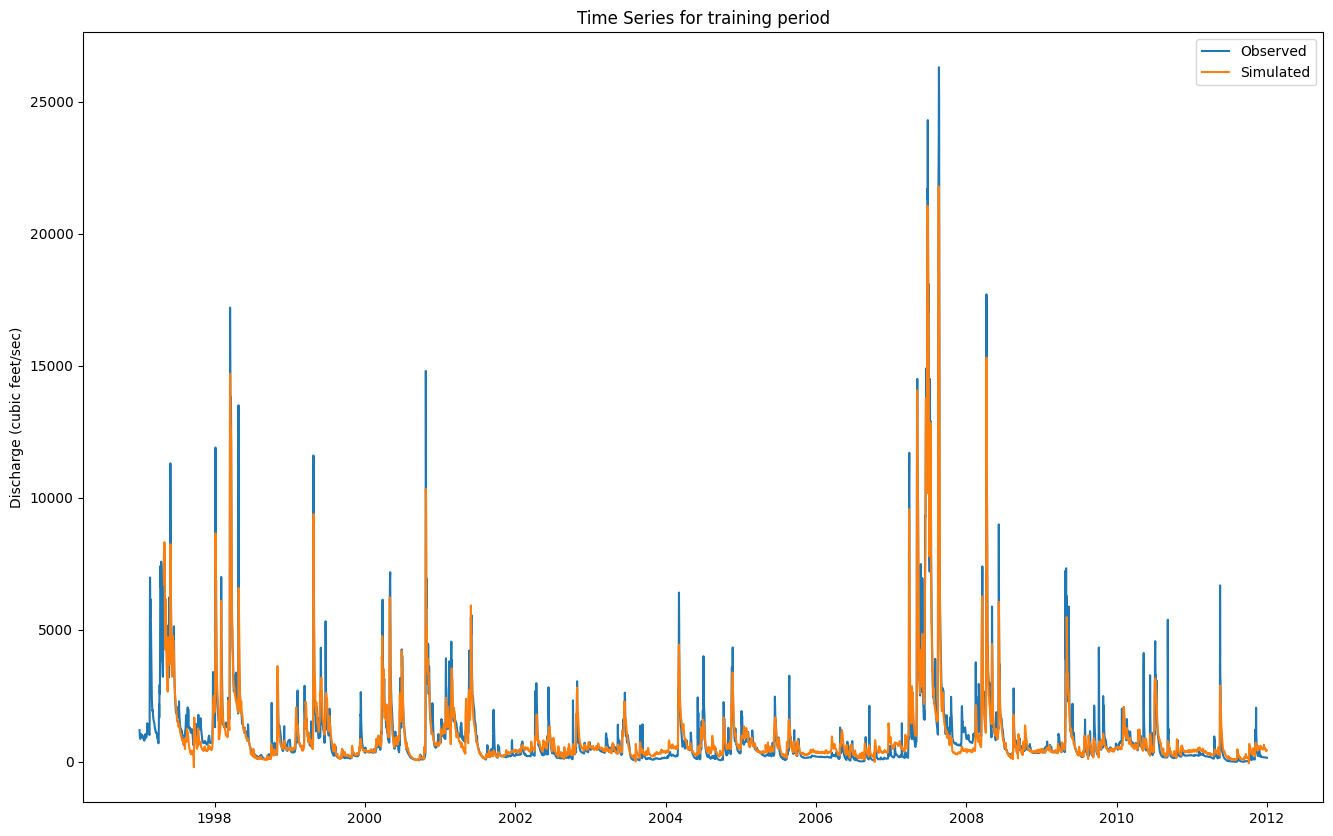

In [7]:
# extract observations and simulations
daily_qobs = results["Washita"]["1D"]["xr"]["QObs_obs"]
daily_qsim = results["Washita"]["1D"]["xr"]["QObs_sim"]

fig, ax = plt.subplots(figsize=(16,10))
ax.plot(daily_qobs["date"], daily_qobs, label="Observed")
ax.plot(daily_qsim["date"], daily_qsim, label="Simulated")
ax.legend()
ax.set_ylabel("Discharge (cubic feet/sec)")
ax.set_title("Time Series for training period")

# Calculate some metrics
values = metrics.calculate_all_metrics(daily_qobs.isel(time_step=-1), daily_qsim.isel(time_step=-1))
print("Daily metrics:")
for key, val in values.items():
    print(f"  {key}: {val:.3f}")

In [8]:
run_dir = Path("/Users/gautam/Research/codesforresearch/percentsaturation/after first review/Voronoi/runs/no_soil_0103_125057")   

# create a tester instance and start evaluation
tester = get_tester(cfg=Config(run_dir / "config.yml"), run_dir=run_dir, period="validation", init_model=True)
results = tester.evaluate(save_results=False, metrics=run_config.metrics)

results.keys()

# Validation: 100%|██████████| 1/1 [00:00<00:00,  1.90it/s]


dict_keys(['Washita'])

Daily metrics:
  NSE: 0.513
  MSE: 1259197.125
  RMSE: 1122.140
  KGE: 0.456
  Alpha-NSE: 1.166
  Beta-KGE: 1.486
  Beta-NSE: 0.205
  Pearson-r: 0.821
  FHV: 23.594
  FMS: -31.691
  FLV: 68.715
  Peak-Timing: 1.889
  Peak-MAPE: 59.062


/Users/gautam/Library/Python/3.9/lib/python/site-packages/neuralhydrology/datautils/utils.py:339: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  offset_one = to_offset(freq_one)
/Users/gautam/Library/Python/3.9/lib/python/site-packages/neuralhydrology/datautils/utils.py:382: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  factor = pd.to_timedelta(freq_one) / pd.to_timedelta(freq_two)


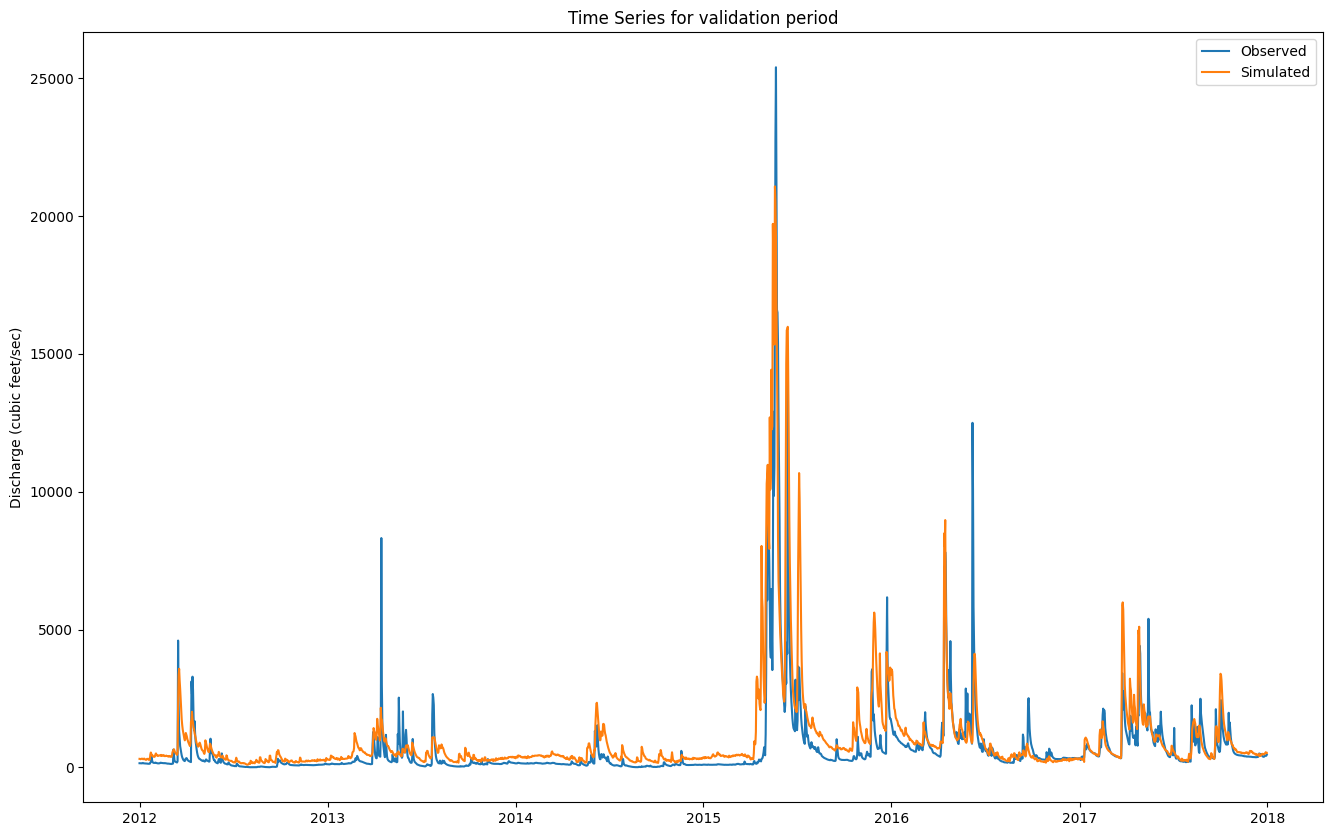

In [9]:
# extract observations and simulations
daily_qobs = results["Washita"]["1D"]["xr"]["QObs_obs"]
daily_qsim_baseline = results["Washita"]["1D"]["xr"]["QObs_sim"]

fig, ax = plt.subplots(figsize=(16,10))
ax.plot(daily_qobs["date"], daily_qobs, label="Observed")
ax.plot(daily_qsim_baseline["date"], daily_qsim_baseline, label="Simulated")
ax.legend()
ax.set_ylabel("Discharge (cubic feet/sec)")
ax.set_title("Time Series for validation period")

# Calculate some metrics
values = metrics.calculate_all_metrics(daily_qobs.isel(time_step=-1), daily_qsim_baseline.isel(time_step=-1))
print("Daily metrics:")
for key, val in values.items():
    print(f"  {key}: {val:.3f}")

In [12]:
run_dir = Path("/Users/gautam/Research/codesforresearch/percentsaturation/after first review/Voronoi/runs/no_soil_1009_125606")   
run_config = Config(Path(run_dir/"config.yml"))
# create a tester instance and start evaluation
tester = get_tester(cfg=Config(run_dir / "config.yml"), run_dir=run_dir, period="test", init_model=True)
results = tester.evaluate(save_results=False, metrics=run_config.metrics)

results.keys()

# Evaluation: 100%|██████████| 1/1 [00:00<00:00,  7.27it/s]


dict_keys(['Washita'])

Daily metrics:
  NSE: 0.317
  MSE: 1791010.750
  RMSE: 1338.286
  KGE: 0.570
  Alpha-NSE: 0.829
  Beta-KGE: 0.982
  Beta-NSE: -0.011
  Pearson-r: 0.606
  FHV: -4.225
  FMS: -47.710
  FLV: 17.744
  Peak-Timing: 1.222
  Peak-MAPE: 63.903


/Users/gautam/Library/Python/3.9/lib/python/site-packages/neuralhydrology/datautils/utils.py:339: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  offset_one = to_offset(freq_one)
/Users/gautam/Library/Python/3.9/lib/python/site-packages/neuralhydrology/datautils/utils.py:382: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  factor = pd.to_timedelta(freq_one) / pd.to_timedelta(freq_two)


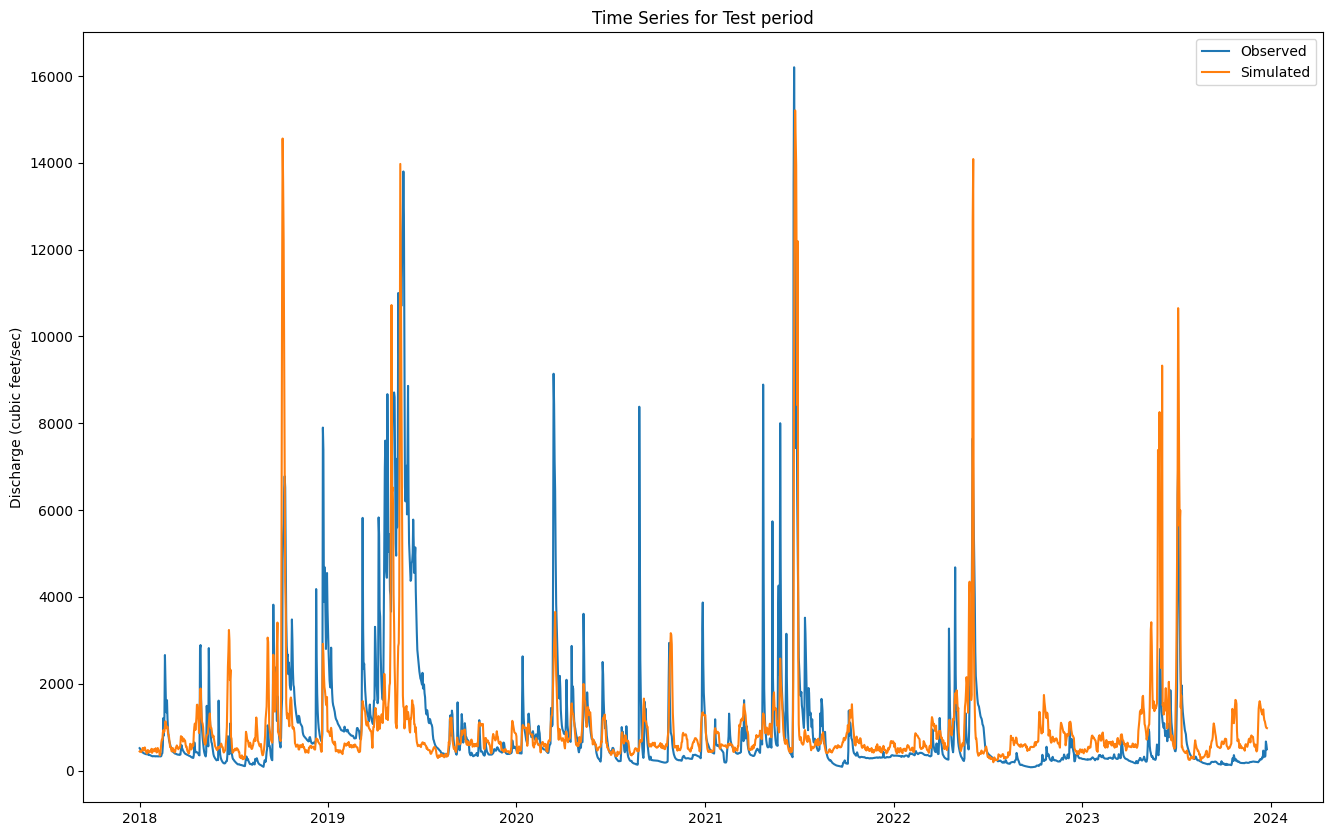

In [13]:
# extract observations and simulations
daily_qobs = results["Washita"]["1D"]["xr"]["QObs_obs"]
daily_qsim_baseline_test = results["Washita"]["1D"]["xr"]["QObs_sim"]

fig, ax = plt.subplots(figsize=(16,10))
ax.plot(daily_qobs["date"], daily_qobs, label="Observed")
ax.plot(daily_qsim_baseline_test["date"], daily_qsim_baseline_test, label="Simulated")
ax.legend()
ax.set_ylabel("Discharge (cubic feet/sec)")
ax.set_title("Time Series for Test period")

# Calculate some metrics
values = metrics.calculate_all_metrics(daily_qobs.isel(time_step=-1), daily_qsim_baseline_test.isel(time_step=-1))
print("Daily metrics:")
for key, val in values.items():
    print(f"  {key}: {val:.3f}")

In [17]:
#2nd Scenario running (with soil moisture)

start_run(config_file=Path("/Users/gautam/Research/codesforresearch/percentsaturation/after first review/Voronoi/2_basin_fortest.yml"))

2026-06-14 16:27:46,008: Logging to /Users/gautam/Research/codesforresearch/percentsaturation/after first review/Voronoi/runs/with_soil_1406_162746/output.log initialized.
2026-06-14 16:27:46,009: ### Folder structure created at /Users/gautam/Research/codesforresearch/percentsaturation/after first review/Voronoi/runs/with_soil_1406_162746
2026-06-14 16:27:46,009: ### Run configurations for with_soil
2026-06-14 16:27:46,010: experiment_name: with_soil
2026-06-14 16:27:46,011: run_dir: /Users/gautam/Research/codesforresearch/percentsaturation/after first review/Voronoi/runs/with_soil_1406_162746
2026-06-14 16:27:46,011: train_basin_file: /Users/gautam/Research/codesforresearch/percentsaturation/after first review/Voronoi/1_basin.txt
2026-06-14 16:27:46,011: validation_basin_file: /Users/gautam/Research/codesforresearch/percentsaturation/after first review/Voronoi/1_basin.txt
2026-06-14 16:27:46,012: test_basin_file: /Users/gautam/Research/codesforresearch/percentsaturation/after first re

In [180]:
run_dir = Path("/Users/gautam/Research/codesforresearch/percentsaturation/after first review/Voronoi/runs/with_soil_1009_184047")   # you'll find this path in the output of the training above.
run_config = Config(Path(run_dir/"config.yml"))
# create a tester instance and start evaluation
tester = get_tester(cfg=Config(run_dir / "config.yml"), run_dir=run_dir, period="train", init_model=True)
results = tester.evaluate(save_results=False, metrics=run_config.metrics)

results.keys()

2025-09-10 18:41:31,773: Using the model weights from /Users/gautam/Research/codesforresearch/percentsaturation/after first review/Voronoi/runs/with_soil_1009_184047/model_epoch005.pt
# Evaluation: 100%|██████████| 1/1 [00:00<00:00,  5.20it/s]


dict_keys(['Washita'])

Daily metrics:
  NSE: 0.581
  MSE: 1323081.750
  RMSE: 1150.253
  KGE: 0.613
  Alpha-NSE: 0.710
  Beta-KGE: 1.105
  Beta-NSE: 0.054
  Pearson-r: 0.766
  FHV: -25.965
  FMS: -40.270
  FLV: 87.136
  Peak-Timing: 1.324
  Peak-MAPE: 47.532


/Users/gautam/Library/Python/3.9/lib/python/site-packages/neuralhydrology/datautils/utils.py:339: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  offset_one = to_offset(freq_one)
/Users/gautam/Library/Python/3.9/lib/python/site-packages/neuralhydrology/datautils/utils.py:382: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  factor = pd.to_timedelta(freq_one) / pd.to_timedelta(freq_two)


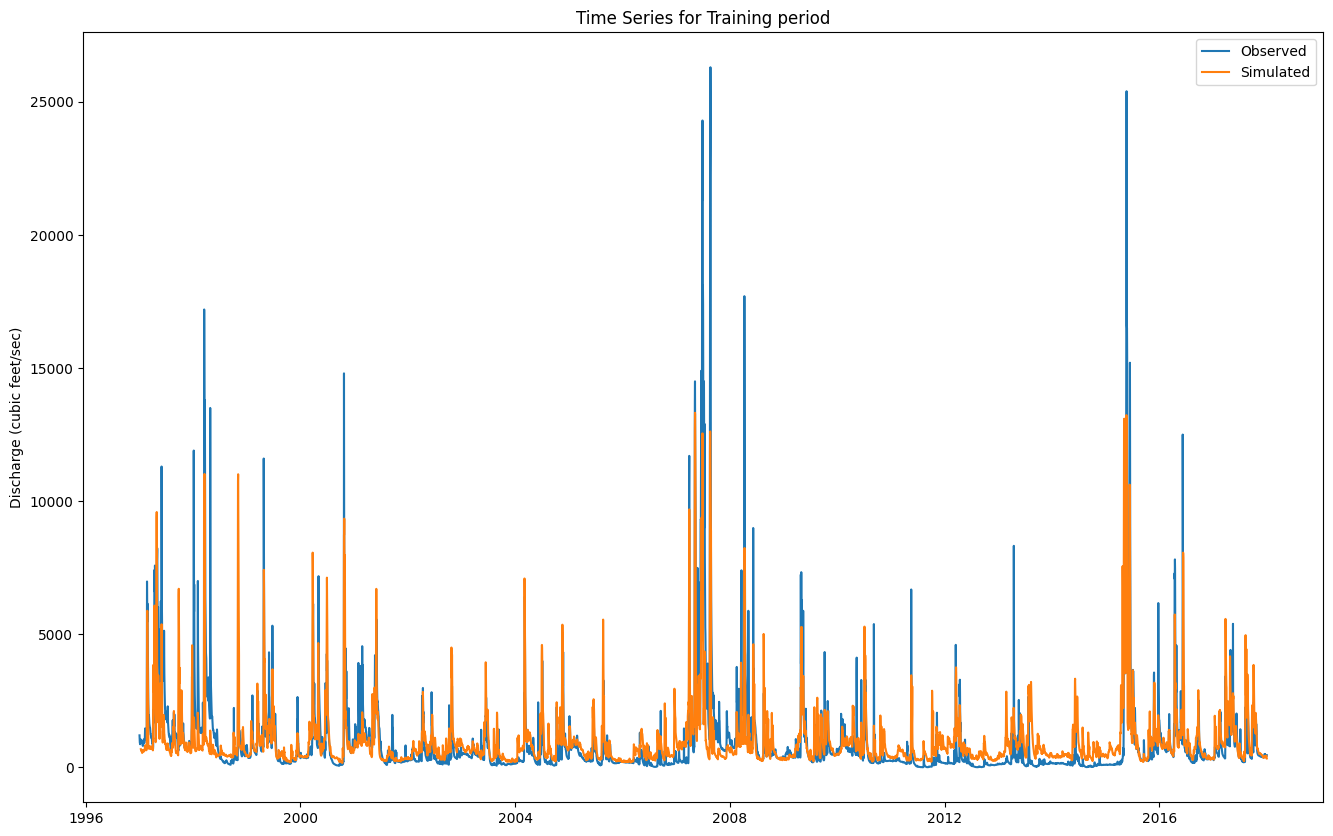

In [181]:
# extract observations and simulations
daily_qobs = results["Washita"]["1D"]["xr"]["QObs_obs"]
daily_qsim = results["Washita"]["1D"]["xr"]["QObs_sim"]

fig, ax = plt.subplots(figsize=(16,10))
ax.plot(daily_qobs["date"], daily_qobs, label="Observed")
ax.plot(daily_qsim["date"], daily_qsim, label="Simulated")
ax.legend()
ax.set_ylabel("Discharge (cubic feet/sec)")
ax.set_title("Time Series for Training period")

# Calculate some metrics
values = metrics.calculate_all_metrics(daily_qobs.isel(time_step=-1), daily_qsim.isel(time_step=-1))
print("Daily metrics:")
for key, val in values.items():
    print(f"  {key}: {val:.3f}")

In [10]:
run_dir = Path("/Users/gautam/Research/codesforresearch/percentsaturation/after first review/Voronoi/runs/with_soil_1908_150022")   # you'll find this path in the output of the training above.
run_config = Config(Path(run_dir/"config.yml"))
# create a tester instance and start evaluation
tester = get_tester(cfg=Config(run_dir / "config.yml"), run_dir=run_dir, period="validation", init_model=True)
results = tester.evaluate(save_results=False, metrics=run_config.metrics)

results.keys()

# Validation: 100%|██████████| 1/1 [00:00<00:00,  4.32it/s]


dict_keys(['Washita'])

Daily metrics:
  NSE: 0.690
  MSE: 802231.812
  RMSE: 895.674
  KGE: 0.701
  Alpha-NSE: 0.815
  Beta-KGE: 1.167
  Beta-NSE: 0.070
  Pearson-r: 0.834
  FHV: -11.294
  FMS: -57.014
  FLV: -533.623
  Peak-Timing: 2.111
  Peak-MAPE: 67.863


/Users/gautam/Library/Python/3.9/lib/python/site-packages/neuralhydrology/datautils/utils.py:339: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  offset_one = to_offset(freq_one)
/Users/gautam/Library/Python/3.9/lib/python/site-packages/neuralhydrology/datautils/utils.py:382: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  factor = pd.to_timedelta(freq_one) / pd.to_timedelta(freq_two)


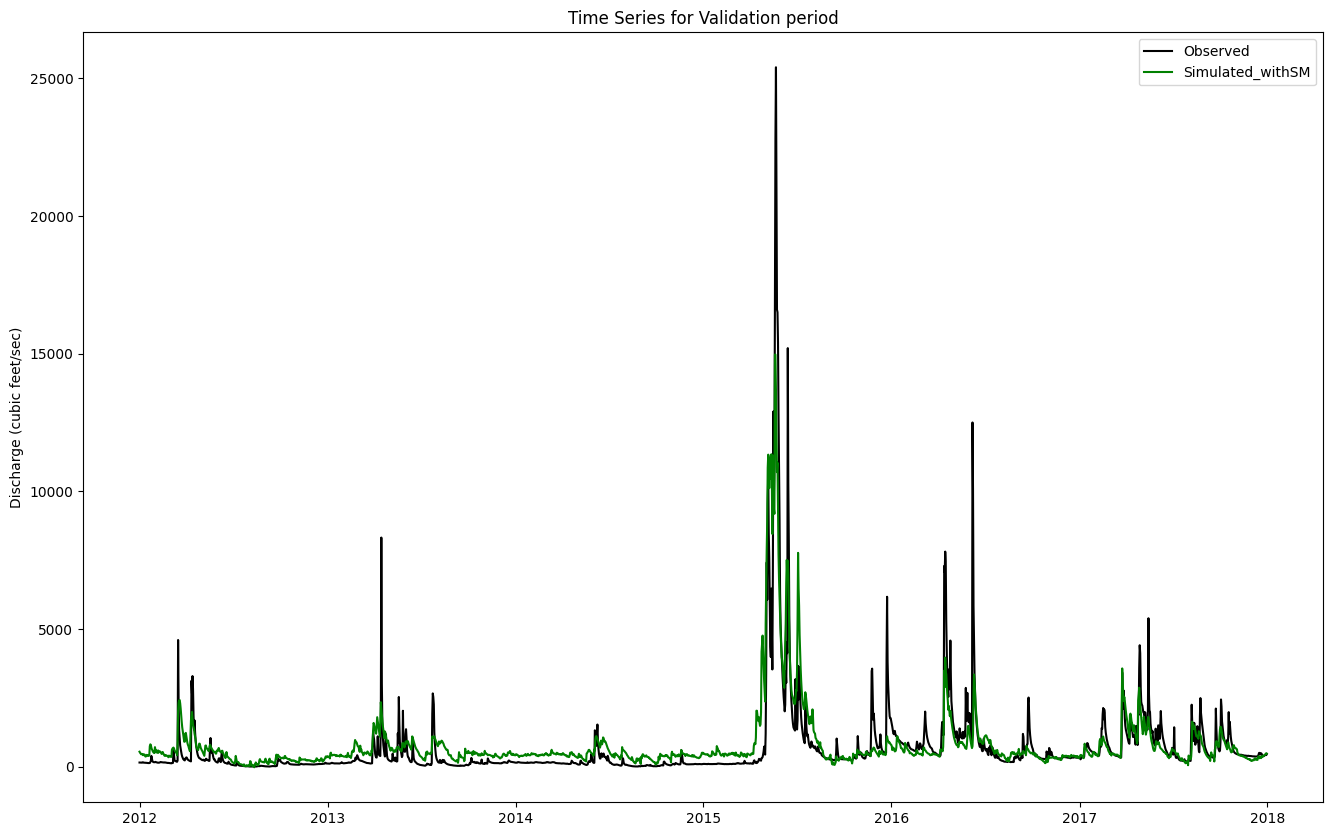

In [35]:
# extract observations and simulations
daily_qobs = results["Washita"]["1D"]["xr"]["QObs_obs"]
daily_qsim = results["Washita"]["1D"]["xr"]["QObs_sim"]

fig, ax = plt.subplots(figsize=(16,10))
ax.plot(daily_qobs["date"], daily_qobs, label="Observed", color = "black")
ax.plot(daily_qsim["date"], daily_qsim, label="Simulated_withSM", color = "green")
#ax.plot(daily_qsim_baseline["date"], daily_qsim_baseline, label="Simulated_baseline", color = "red")
ax.legend()
ax.set_ylabel("Discharge (cubic feet/sec)")
ax.set_title("Time Series for Validation period")

# Calculate some metrics
values = metrics.calculate_all_metrics(daily_qobs.isel(time_step=-1), daily_qsim.isel(time_step=-1))
print("Daily metrics:")
for key, val in values.items():
    print(f"  {key}: {val:.3f}")

In [19]:
run_dir = Path("/Users/gautam/Research/codesforresearch/percentsaturation/after first review/Voronoi/runs/with_soil_1406_162746")   # you'll find this path in the output of the training above.
run_config = Config(Path(run_dir/"config.yml"))
# create a tester instance and start evaluation
tester = get_tester(cfg=Config(run_dir / "config.yml"), run_dir=run_dir, period="test", init_model=True)
results = tester.evaluate(save_results=False, metrics=run_config.metrics)

results.keys()

2026-06-14 16:31:54,887: Using the model weights from /Users/gautam/Research/codesforresearch/percentsaturation/after first review/Voronoi/runs/with_soil_1406_162746/model_epoch028.pt
# Evaluation: 100%|██████████| 1/1 [00:00<00:00,  3.02it/s]


dict_keys(['Washita'])

Daily metrics:
  NSE: 0.651
  MSE: 914132.125
  RMSE: 956.103
  KGE: 0.591
  Alpha-NSE: 0.674
  Beta-KGE: 0.824
  Beta-NSE: -0.106
  Pearson-r: 0.828
  FHV: -31.594
  FMS: -26.055
  FLV: -1840.471
  Peak-Timing: 1.333
  Peak-MAPE: 60.151


/Users/gautam/Library/Python/3.9/lib/python/site-packages/neuralhydrology/datautils/utils.py:339: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  offset_one = to_offset(freq_one)
/Users/gautam/Library/Python/3.9/lib/python/site-packages/neuralhydrology/datautils/utils.py:382: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  factor = pd.to_timedelta(freq_one) / pd.to_timedelta(freq_two)


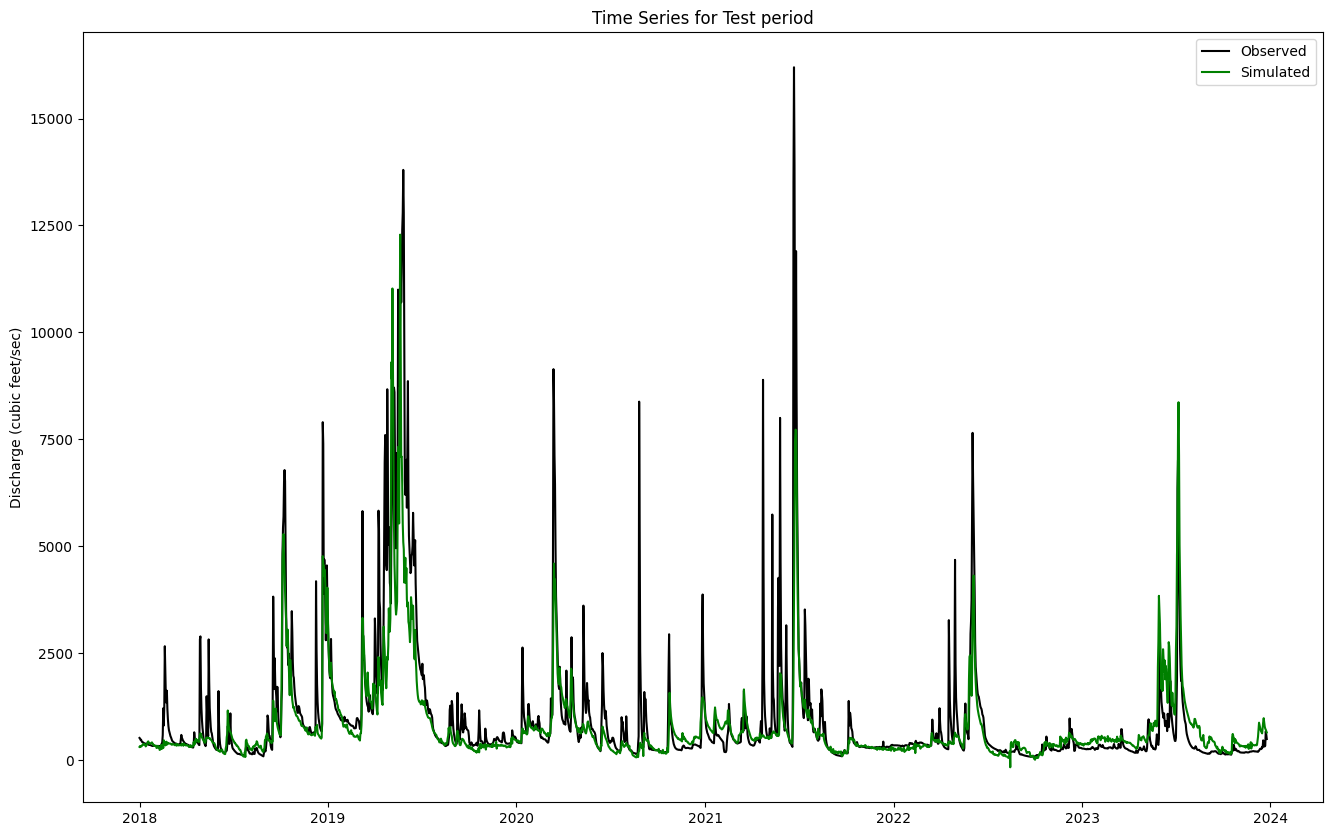

In [20]:
# extract observations and simulations
daily_qobs = results["Washita"]["1D"]["xr"]["QObs_obs"]
daily_qsim = results["Washita"]["1D"]["xr"]["QObs_sim"]

fig, ax = plt.subplots(figsize=(16,10))
ax.plot(daily_qobs["date"], daily_qobs, label="Observed", color = "black")
ax.plot(daily_qsim["date"], daily_qsim, label="Simulated", color = "green")
#ax.plot(daily_qsim_baseline_test["date"], daily_qsim_baseline_test, label="Simulated_baseline", color = "red")
ax.legend()
ax.set_ylabel("Discharge (cubic feet/sec)")
ax.set_title("Time Series for Test period")

# Calculate some metrics
values = metrics.calculate_all_metrics(daily_qobs.isel(time_step=-1), daily_qsim.isel(time_step=-1))
print("Daily metrics:")
for key, val in values.items():
    print(f"  {key}: {val:.3f}")